# M1 — Comparing the four models, and choosing one for the collar

**Project:** Bio-Inspired Medicinal Plant Species Crowd-sourcing Using Goats
**Course:** CSC 3118 — Computer Science Project I

All four models were trained from scratch on **the same windows** with **the
same segment-based split**. So any difference below comes from the model, not
the data. This notebook:

1. Collects the four results files into one table.
2. Reloads each saved model and re-scores the test set, to confirm the numbers.
3. Draws the comparison figures for the report.
4. Puts **confidence intervals** on every score, so we can tell real
   differences from luck.
5. Checks whether the most accurate model can be **made small enough** for the collar.
6. Applies a **stated selection rule** and names the model that goes on the collar.

**Run order:** Kernel → Restart Kernel and Run All Cells. Keep this notebook in the
same folder as the others. It takes about 3–6 minutes, most of it the
compact-forest check in Step 5.

In [1]:
# =============================================================================
# CONFIGURATION
# =============================================================================
OUT_DIR = "outputs_kamminga"
DATA_FILE = "windows_kamminga.npz"

TAGS = ["M1_2_RandomForest", "M1_3_1D_CNN", "M1_4_LSTM", "M1_5_CNN_LSTM"]

# One fixed colour per model, used in every figure (colour-blind-safe order).
MODEL_COLORS = {
    "Random Forest": "#2a78d6",
    "1D CNN":        "#eb6834",
    "LSTM":          "#1baf7a",
    "CNN-LSTM":      "#eda100",
}
MODEL_MARKERS = {"Random Forest": "o", "1D CNN": "s", "LSTM": "^", "CNN-LSTM": "D"}

# ---- The selection rule (Step 6) --------------------------------------------
# The collar's microcontroller must also hold the firmware, the camera driver
# and image buffers, so we give the M1 model a budget of 1 MB of storage.
MEMORY_BUDGET_MB = 1.0

N_BOOTSTRAP = 1000       # resamples for the confidence intervals
RANDOM_SEED = 42

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, average_precision_score, precision_recall_curve,
                             recall_score, precision_score)

RESULTS_DIR = os.path.join(OUT_DIR, "results")
FIG_DIR = os.path.join(OUT_DIR, "figures")
MODEL_DIR = os.path.join(OUT_DIR, "models")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 10,
})
INK = "#1f2933"
MUTED = "#9aa5b1"
rng = np.random.default_rng(RANDOM_SEED)

## Step 1 — The four results side by side

In [7]:
# =============================================================================
# LOAD THE FOUR RESULTS FILES
# =============================================================================
R = {}
for tag in TAGS:
    p = os.path.join(RESULTS_DIR, f"{tag}.json")
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing {p}. Run the {tag} notebook first.")
    r = json.load(open(p))
    R[r["model"]] = r
MODELS = list(R)


def on_collar_mb(r):
    """Estimated storage on the microcontroller.
    Neural networks: one byte per weight after INT8 compression.
    Random Forest: about 12 bytes per tree node (feature index, threshold,
    two child pointers, leaf value)."""
    if "parameters" in r["complexity"]:
        return r["complexity"]["parameters"] / 1e6
    return r["complexity"]["tree_nodes"] * 12 / 1e6


table = pd.DataFrame({
    m: {
        "F1 (chosen threshold)": r["test"]["f1"],
        "F1 (threshold 0.5)": r["test_at_0.5"]["f1"],
        "Recall": r["test"]["recall"],
        "Precision": r["test"]["precision"],
        "Specificity": r["test"]["specificity"],
        "PR-AUC": r["test"]["pr_auc"],
        "ROC-AUC": r["test"]["roc_auc"],
        "Threshold": r["threshold"],
        "Weights / tree nodes": r["complexity"].get("parameters", r["complexity"].get("tree_nodes")),
        "Saved file (MB)": r["model_size_mb"],
        "On-collar estimate (MB)": on_collar_mb(r),
        "ms per window (laptop)": r["ms_per_window"],
        "Training time (min)": r["train_seconds"] / 60,
    } for m, r in R.items()
})
table.to_csv(os.path.join(RESULTS_DIR, "M1_comparison_table.csv"))
print("Saved: M1_comparison_table.csv  (paste this table into the report)")
table.round(4)

Saved: M1_comparison_table.csv  (paste this table into the report)


,Random Forest,1D CNN,LSTM,CNN-LSTM
F1 (chosen threshold),0.8234,0.7432,0.6519,0.7645
F1 (threshold 0.5),0.8474,0.7796,0.6747,0.7407
Recall,0.9441,0.9492,0.8203,0.9407
Precision,0.7300,0.6107,0.5408,0.6439
Specificity,0.9609,0.9322,0.9220,0.9417
PR-AUC,0.9453,0.9099,0.7360,0.8940
ROC-AUC,0.9913,0.9869,0.9477,0.9860
Threshold,0.4400,0.3900,0.4400,0.5800
Weights / tree nodes,204998.0000,111425.0000,31681.0000,67841.0000
Saved file (MB),6.1930,1.4210,0.4280,0.8940


### A note on the timing row

The Random Forest's time includes computing its 166 features **in Python**, one
window at a time. The neural networks run as compiled TensorFlow graphs. On the
collar both would be compiled C code, so treat this row as a rough ranking,
not as the collar's real speed. Every model decides in well under the 2 seconds
a window lasts.

## Step 2 — Reload every model and re-score the test set

This confirms the saved numbers are reproducible, and it gives us each model's
predictions window by window, which Steps 3 and 4 need.

In [4]:
# =============================================================================
# DATA
# =============================================================================
d = np.load(os.path.join(OUT_DIR, DATA_FILE), allow_pickle=True)
splits = d["splits"]
tr, va, te = (splits == "train"), (splits == "val"), (splits == "test")
y = d["y"].astype(np.int64)
labels = d["labels"]
segments = d["segments"]
channels = [str(c) for c in d["channels"]]
FS = int(d["sample_rate_hz"][0])
X_raw = d["X"]
X_norm = ((X_raw - d["channel_mean"]) / d["channel_std"]).astype(np.float32)
y_te, y_va = y[te], y[va]
print(f"Test: {te.sum():,} windows, {y_te.sum():,} eating, {len(np.unique(segments[te]))} segments")

Test: 5,857 windows, 590 eating, 394 segments


In [5]:
# =============================================================================
# THE RANDOM FOREST'S FEATURES  (identical to M1_2_Random_Forest.ipynb)
# =============================================================================
BANDS = [(0, 2), (2, 5), (5, 10), (10, 20), (20, FS / 2)]
PAIRS = [(0, 1), (0, 2), (1, 2), (3, 4), (3, 5), (4, 5)]


def extract_features(Xb, fs=FS):
    Xb = Xb.astype(np.float64)
    n, T, _ = Xb.shape
    acc_mag = np.linalg.norm(Xb[:, :, 0:3], axis=2, keepdims=True)
    gyr_mag = np.linalg.norm(Xb[:, :, 3:6], axis=2, keepdims=True)
    S = np.concatenate([Xb, acc_mag, gyr_mag], axis=2)
    mean = S.mean(1); std = S.std(1); cen = S - mean[:, None, :]
    q25, q50, q75, q90 = np.percentile(S, [25, 50, 75, 90], axis=1)
    mn, mx = S.min(1), S.max(1)
    rms = np.sqrt((S ** 2).mean(1)); eps = 1e-9
    skew = (cen ** 3).mean(1) / (std ** 3 + eps)
    kurt = (cen ** 4).mean(1) / (std ** 4 + eps) - 3.0
    jerk = np.abs(np.diff(S, axis=1)).mean(1)
    zcr = (np.diff(np.signbit(cen), axis=1)).mean(1)
    power = np.abs(np.fft.rfft(cen, axis=1)) ** 2
    freqs = np.fft.rfftfreq(T, 1.0 / fs)
    total = power.sum(1) + eps
    dom = freqs[power[:, 1:, :].argmax(1) + 1]
    bands = [power[:, (freqs >= a) & (freqs < b), :].sum(1) / total for a, b in BANDS]
    p = power / total[:, None, :]
    ent = -(p * np.log(p + eps)).sum(1) / np.log(power.shape[1])
    per_signal = [mean, q50, mn, mx, mx - mn, std, q75 - q25, rms,
                  skew, kurt, jerk, zcr, dom] + bands + [ent, q90]
    block = np.stack(per_signal, axis=2).reshape(n, -1)
    corrs = [(cen[:, :, i] * cen[:, :, j]).mean(1) / (std[:, i] * std[:, j] + eps) for i, j in PAIRS]
    return np.concatenate([block, np.stack(corrs, axis=1)], axis=1).astype(np.float32)


F = np.concatenate([extract_features(X_raw[s:s + 2000]) for s in range(0, len(X_raw), 2000)])
print("Feature table:", F.shape)

Feature table: (39775, 166)


In [6]:
# =============================================================================
# RE-SCORE EVERY MODEL
# =============================================================================
import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel("ERROR")          # hide harmless retracing warnings

P_TEST = {}
for tag in TAGS:
    name = [m for m in MODELS if R[m]["tag"] == tag][0]
    if tag == "M1_2_RandomForest":
        rf = joblib.load(os.path.join(MODEL_DIR, f"{tag}.joblib"))
        P_TEST[name] = rf.predict_proba(F[te])[:, 1]
    else:
        net = keras.models.load_model(os.path.join(MODEL_DIR, f"{tag}.keras"))
        P_TEST[name] = net.predict(X_norm[te], batch_size=256, verbose=0).ravel()

print(f"{'model':<15} {'saved F1':>9} {'re-scored':>10}   match?")
for m in MODELS:
    f1_now = f1_score(y_te, (P_TEST[m] >= R[m]["threshold"]).astype(int))
    ok = abs(f1_now - R[m]["test"]["f1"]) < 0.005
    print(f"{m:<15} {R[m]['test']['f1']:>9.4f} {f1_now:>10.4f}   {'yes' if ok else 'NO - rerun that notebook'}")

model            saved F1  re-scored   match?
Random Forest      0.8234     0.8234   yes
1D CNN             0.7432     0.7432   yes
LSTM               0.6519     0.6519   yes
CNN-LSTM           0.7645     0.7645   yes


## Step 3 — Figures for the report

### 3a. The headline scores

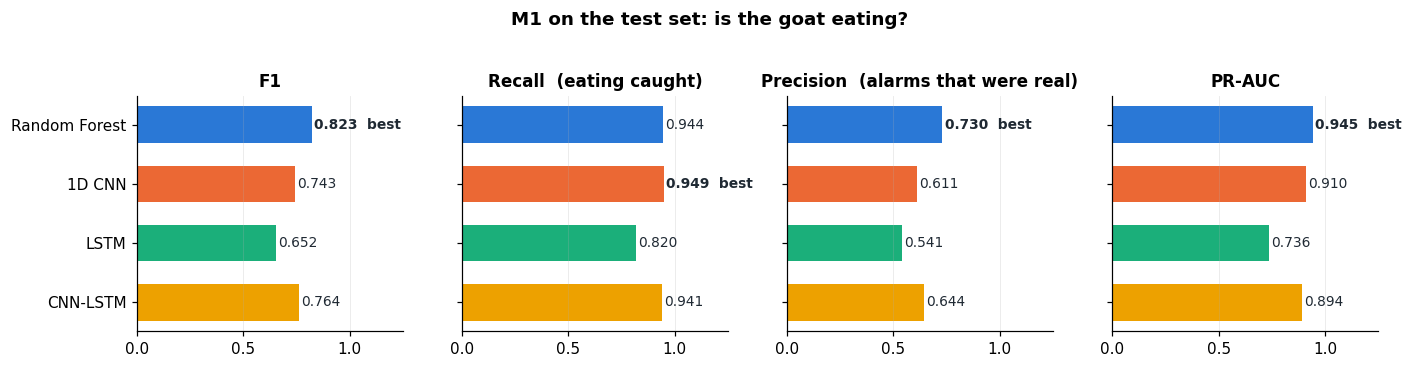

In [8]:
# =============================================================================
# FIGURE: FOUR METRICS, FOUR MODELS  (small multiples, one panel per metric)
# =============================================================================
metrics = [("F1 (chosen threshold)", "F1"), ("Recall", "Recall  (eating caught)"),
           ("Precision", "Precision  (alarms that were real)"), ("PR-AUC", "PR-AUC")]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), sharey=True)
order = MODELS[::-1]
for ax, (key, title) in zip(axes, metrics):
    vals = [table.loc[key, m] for m in order]
    best = max(vals)
    ax.barh(order, vals, color=[MODEL_COLORS[m] for m in order], height=0.62)
    for yi, v in enumerate(vals):
        ax.text(v + 0.01, yi, f"{v:.3f}" + ("  best" if v == best else ""),
                va="center", fontsize=9, color=INK,
                fontweight="bold" if v == best else "normal")
    ax.set_xlim(0, 1.25); ax.set_xticks([0, 0.5, 1.0])
    ax.set_title(title); ax.grid(axis="y", visible=False)
plt.suptitle("M1 on the test set: is the goat eating?", fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M1_compare_scores.png"), bbox_inches="tight")
plt.show()

### 3b. Precision–recall curves

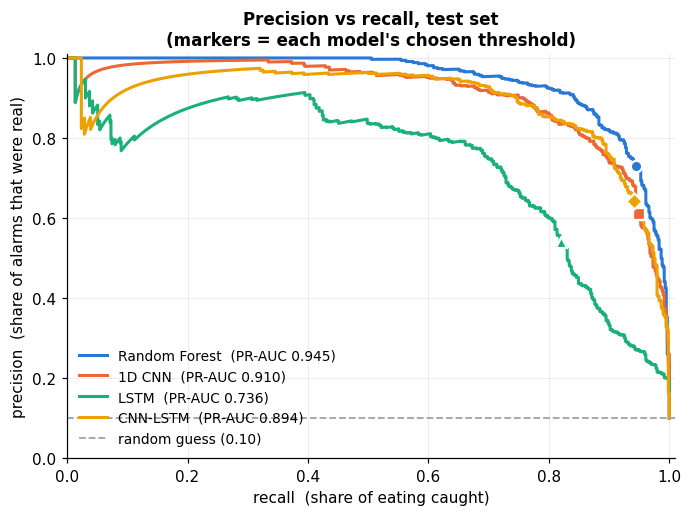

In [9]:
# =============================================================================
# FIGURE: ALL FOUR PRECISION-RECALL CURVES
# =============================================================================
fig, ax = plt.subplots(figsize=(6.4, 4.8))
for m in MODELS:
    prec, rec, _ = precision_recall_curve(y_te, P_TEST[m])
    ax.plot(rec, prec, color=MODEL_COLORS[m], linewidth=2,
            label=f"{m}  (PR-AUC {R[m]['test']['pr_auc']:.3f})")
    ax.scatter([R[m]["test"]["recall"]], [R[m]["test"]["precision"]], s=55,
               color=MODEL_COLORS[m], marker=MODEL_MARKERS[m],
               edgecolor="white", linewidth=1.5, zorder=3)
ax.axhline(y_te.mean(), color=MUTED, linewidth=1.2, linestyle="--",
           label=f"random guess ({y_te.mean():.2f})")
ax.set_xlim(0, 1.01); ax.set_ylim(0, 1.01)
ax.set_xlabel("recall  (share of eating caught)")
ax.set_ylabel("precision  (share of alarms that were real)")
ax.set_title("Precision vs recall, test set\n(markers = each model's chosen threshold)")
ax.legend(loc="lower left", frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M1_compare_pr_curves.png"))
plt.show()

### 3c. What fools each model?

Each cell is the share of that activity's test windows the model flagged as
eating. The **grazing** column is recall (higher is better). Every other column
is a false-alarm rate (lower is better).

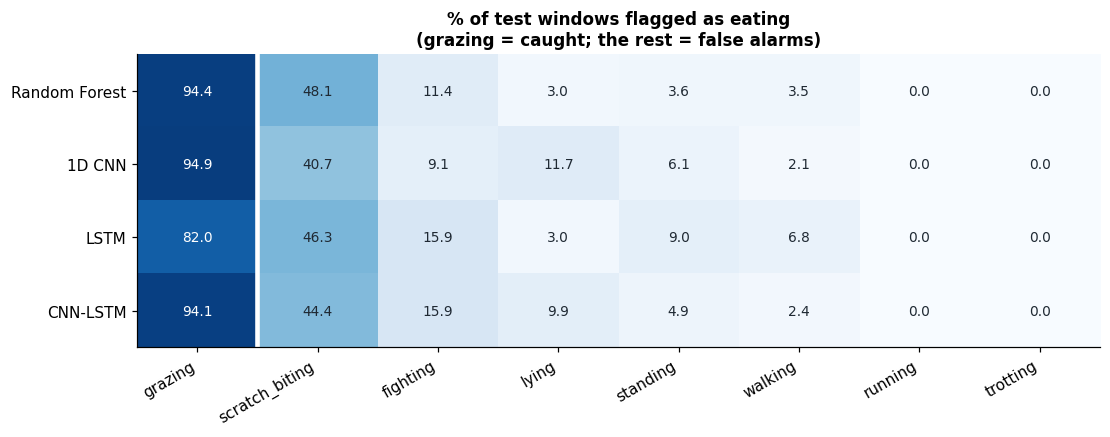

,grazing,scratch_biting,fighting,lying,standing,walking,running,trotting
Random Forest,94.4,48.1,11.4,3.0,3.6,3.5,0.0,0.0
1D CNN,94.9,40.7,9.1,11.7,6.1,2.1,0.0,0.0
LSTM,82.0,46.3,15.9,3.0,9.0,6.8,0.0,0.0
CNN-LSTM,94.1,44.4,15.9,9.9,4.9,2.4,0.0,0.0


In [10]:
# =============================================================================
# FIGURE: FALSE ALARMS BY ACTIVITY  (heatmap)
# =============================================================================
fa = pd.DataFrame({m: R[m]["false_alarm_by_activity"] for m in MODELS}).T
cols = ["grazing"] + sorted([c for c in fa.columns if c != "grazing"],
                            key=lambda c: -fa[c].mean())
fa = fa[cols] * 100

fig, ax = plt.subplots(figsize=(1.0 * len(cols) + 2.2, 0.62 * len(MODELS) + 1.6))
ax.imshow(fa.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.grid(False)
ax.set_xticks(range(len(cols)), cols, rotation=30, ha="right")
ax.set_yticks(range(len(MODELS)), fa.index)
for i in range(fa.shape[0]):
    for j in range(fa.shape[1]):
        v = fa.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9,
                color="white" if v > 55 else INK)
ax.axvline(0.5, color="white", linewidth=3)
ax.set_title("% of test windows flagged as eating\n(grazing = caught; the rest = false alarms)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M1_compare_false_alarms.png"))
plt.show()
fa.round(1)

## Step 4 — Are the differences real? Confidence intervals

The test set holds only a few hundred segments, and some activities appear in a
handful of them. A different draw of segments could shift the scores. To see how
much, we **resample the test set 1,000 times**, drawing whole segments with
replacement (never single windows, which would re-introduce the overlap
problem), and re-score every model on each resample.

The 2.5th and 97.5th percentiles give a **95% confidence interval**. The
bottom table asks directly: *in what share of resamples did the best model beat
each of the others?* Above 95% is a difference you can defend. Below that, the
honest word is "comparable".

In [11]:
# =============================================================================
# SEGMENT BOOTSTRAP
# =============================================================================
te_idx = np.where(te)[0]
seg_te = segments[te]
uniq = np.unique(seg_te)
rows_of = {s: np.where(seg_te == s)[0] for s in uniq}

boot = {m: {"F1": [], "PR-AUC": []} for m in MODELS}
t0 = time.time()
for b in range(N_BOOTSTRAP):
    pick = rng.choice(uniq, size=len(uniq), replace=True)
    idx = np.concatenate([rows_of[s] for s in pick])
    yb = y_te[idx]
    if yb.sum() == 0 or yb.sum() == len(yb):
        continue
    for m in MODELS:
        pb = P_TEST[m][idx]
        boot[m]["F1"].append(f1_score(yb, (pb >= R[m]["threshold"]).astype(int), zero_division=0))
        boot[m]["PR-AUC"].append(average_precision_score(yb, pb))
print(f"{len(boot[MODELS[0]]['F1'])} resamples in {time.time() - t0:.0f}s")

ci = pd.DataFrame({
    m: {f"{k} {q}": np.percentile(boot[m][k], p)
        for k in ["F1", "PR-AUC"] for q, p in [("low", 2.5), ("mid", 50), ("high", 97.5)]}
    for m in MODELS}).T
print("\n95% confidence intervals (segment bootstrap):")
print(ci.round(3).to_string())

best_m = max(MODELS, key=lambda m: np.median(boot[m]["PR-AUC"]))
print(f"\nShare of resamples in which {best_m} beats each other model:")
for m in MODELS:
    if m == best_m:
        continue
    wins_pr = np.mean(np.array(boot[best_m]["PR-AUC"]) > np.array(boot[m]["PR-AUC"]))
    wins_f1 = np.mean(np.array(boot[best_m]["F1"]) > np.array(boot[m]["F1"]))
    print(f"  vs {m:<12}  PR-AUC {wins_pr:6.1%}    F1 {wins_f1:6.1%}")

1000 resamples in 19s

95% confidence intervals (segment bootstrap):
               F1 low  F1 mid  F1 high  PR-AUC low  PR-AUC mid  PR-AUC high
Random Forest   0.660   0.821    0.897       0.880       0.947        0.974
1D CNN          0.518   0.740    0.879       0.807       0.911        0.960
LSTM            0.465   0.650    0.755       0.578       0.749        0.849
CNN-LSTM        0.555   0.762    0.885       0.764       0.897        0.953

Share of resamples in which Random Forest beats each other model:
  vs 1D CNN        PR-AUC  98.9%    F1  93.9%
  vs LSTM          PR-AUC 100.0%    F1 100.0%
  vs CNN-LSTM      PR-AUC  99.5%    F1  88.4%


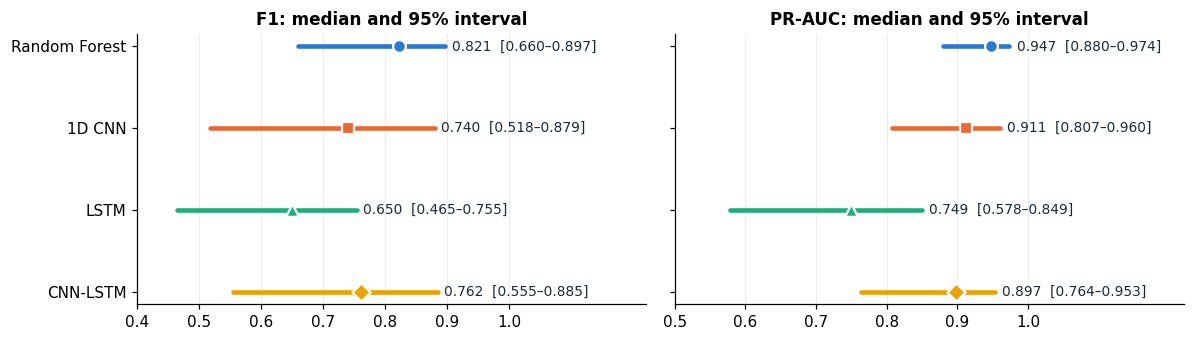

In [12]:
# =============================================================================
# FIGURE: CONFIDENCE INTERVALS
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, k in zip(axes, ["F1", "PR-AUC"]):
    for yi, m in enumerate(MODELS[::-1]):
        lo, mid, hi = ci.loc[m, f"{k} low"], ci.loc[m, f"{k} mid"], ci.loc[m, f"{k} high"]
        ax.plot([lo, hi], [yi, yi], color=MODEL_COLORS[m], linewidth=3, solid_capstyle="round")
        ax.scatter([mid], [yi], color=MODEL_COLORS[m], marker=MODEL_MARKERS[m], s=70,
                   edgecolor="white", linewidth=1.5, zorder=3)
        ax.text(hi + 0.01, yi, f"{mid:.3f}  [{lo:.3f}–{hi:.3f}]", va="center", fontsize=9, color=INK)
    ax.set_yticks(range(len(MODELS)), MODELS[::-1])
    lo_all = ci[f"{k} low"].min()
    x0 = max(0.0, np.floor((lo_all - 0.05) * 10) / 10)
    ax.set_xlim(x0, 1.22)
    ax.set_xticks(np.round(np.arange(x0, 1.0001, 0.1), 1))   # scores stop at 1.0
    ax.set_title(f"{k}: median and 95% interval")
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M1_compare_confidence.png"))
plt.show()

## Step 5 — Can the Random Forest be made to fit the collar?

At full size the forest has about 205,000 tree nodes, roughly **2.5 MB** on a
microcontroller, which breaks the 1 MB budget. A forest can be shrunk by using
fewer trees and capping how deep each tree may grow. The question is how much
accuracy that costs.

We train three smaller forests on the **same training features**, pick each
one's threshold on validation, and score them on test. These aren't new models.
They are deployment-sized versions of Model 1, and the report should present
them that way.

In [13]:
# =============================================================================
# COMPACT FORESTS
# =============================================================================
COMPACT = [
    {"n_estimators": 100, "max_depth": 12},
    {"n_estimators": 50,  "max_depth": 10},
    {"n_estimators": 30,  "max_depth": 8},
]
thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)
compact_rows = []
P_COMPACT = {}
for cfg in COMPACT:
    t0 = time.time()
    crf = RandomForestClassifier(class_weight="balanced", min_samples_leaf=5,
                                 n_jobs=-1, random_state=RANDOM_SEED, **cfg)
    crf.fit(F[tr], y[tr])
    pv = crf.predict_proba(F[va])[:, 1]
    f1s = np.array([f1_score(y_va, (pv >= t).astype(int), zero_division=0) for t in thresholds])
    tied = thresholds[f1s >= f1s.max() - 1e-9]
    thr = float(tied[np.argmin(np.abs(tied - 0.5))])
    pt = crf.predict_proba(F[te])[:, 1]
    nodes = int(sum(t.tree_.node_count for t in crf.estimators_))
    name = f"RF {cfg['n_estimators']} trees, depth {cfg['max_depth']}"
    P_COMPACT[name] = (pt, thr)
    compact_rows.append({
        "model": name,
        "F1": f1_score(y_te, (pt >= thr).astype(int)),
        "Recall": recall_score(y_te, (pt >= thr).astype(int)),
        "Precision": precision_score(y_te, (pt >= thr).astype(int), zero_division=0),
        "PR-AUC": average_precision_score(y_te, pt),
        "tree nodes": nodes,
        "On-collar estimate (MB)": nodes * 12 / 1e6,
        "fit (s)": time.time() - t0,
    })
compact = pd.DataFrame(compact_rows).set_index("model")
full = R["Random Forest"]
compact.loc["RF full (300 trees, depth 20)"] = [
    full["test"]["f1"], full["test"]["recall"], full["test"]["precision"], full["test"]["pr_auc"],
    full["complexity"]["tree_nodes"], on_collar_mb(full), full["train_seconds"]]
compact = compact.iloc[[-1, 0, 1, 2]]
compact.to_csv(os.path.join(RESULTS_DIR, "M1_compact_forest.csv"))
compact.round(4)

,F1,Recall,Precision,PR-AUC,tree nodes,On-collar estimate (MB),fit (s)
model,,,,,,,
"RF full (300 trees, depth 20)",0.8234,0.9441,0.7300,0.9453,204998.0,2.4600,88.0000
"RF 100 trees, depth 12",0.8113,0.9508,0.7074,0.9375,48410.0,0.5809,7.1663
"RF 50 trees, depth 10",0.8023,0.9322,0.7042,0.9251,18384.0,0.2206,4.0768
"RF 30 trees, depth 8",0.7974,0.9339,0.6957,0.9250,7084.0,0.0850,2.1582


## Step 6 — The trade-off, and the choice

The chart below puts every candidate on two axes at once: how well it detects
eating (PR-AUC), and how much collar memory it needs. The shaded region is the
1 MB budget. **The best model is the highest point inside the shaded region.**

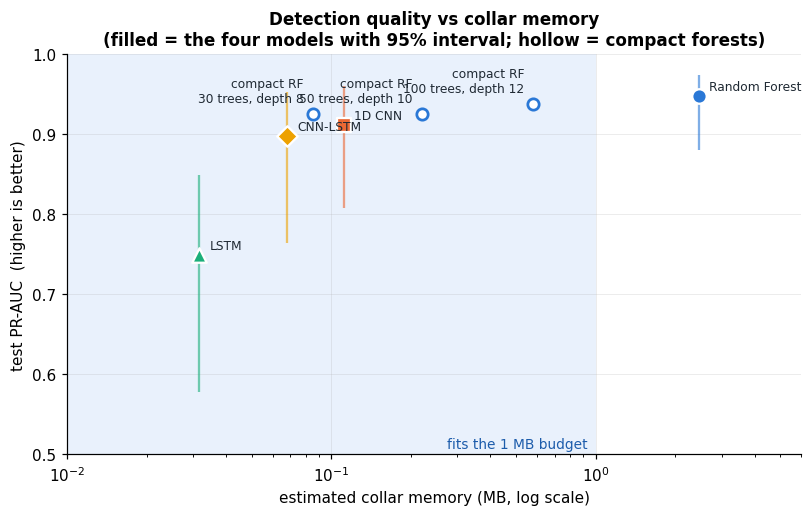

In [14]:
# =============================================================================
# FIGURE: ACCURACY vs COLLAR MEMORY
# =============================================================================
fig, ax = plt.subplots(figsize=(7.6, 4.8))
all_y = list(ci["PR-AUC low"]) + list(compact["PR-AUC"])
y_lo = max(0.0, np.floor((min(all_y) - 0.03) * 20) / 20)
ax.axvspan(1e-3, MEMORY_BUDGET_MB, color="#86b6ef", alpha=0.18, lw=0)
ax.text(MEMORY_BUDGET_MB * 0.93, y_lo + 0.008, f"fits the {MEMORY_BUDGET_MB:g} MB budget",
        ha="right", fontsize=9, color="#1c5cab")

pts = []
for m in MODELS:
    xm, ym = on_collar_mb(R[m]), ci.loc[m, "PR-AUC mid"]
    lo, hi = ci.loc[m, "PR-AUC low"], ci.loc[m, "PR-AUC high"]
    ax.errorbar(xm, ym, yerr=[[ym - lo], [hi - ym]], fmt="none",
                ecolor=MODEL_COLORS[m], elinewidth=1.5, alpha=0.6)
    ax.scatter(xm, ym, s=90, color=MODEL_COLORS[m], marker=MODEL_MARKERS[m],
               edgecolor="white", linewidth=1.5, zorder=3)
    pts.append((m, xm, ym, (7, 4)))
for name, row in compact.iloc[1:].iterrows():
    ax.scatter(row["On-collar estimate (MB)"], row["PR-AUC"], s=55, color="white",
               edgecolor=MODEL_COLORS["Random Forest"], linewidth=1.8, zorder=3)
    pts.append((name.replace("RF ", "compact RF\n"), row["On-collar estimate (MB)"], row["PR-AUC"], (-6, 8)))
for label, xm, ym, off in pts:
    ax.annotate(label, (xm, ym), xytext=off, textcoords="offset points", fontsize=8, color=INK,
                ha="left" if off[0] > 0 else "right")

ax.set_xscale("log")
ax.set_xlim(0.01, 6); ax.set_ylim(y_lo, 1.0)
ax.set_xlabel("estimated collar memory (MB, log scale)")
ax.set_ylabel("test PR-AUC  (higher is better)")
ax.set_title("Detection quality vs collar memory\n(filled = the four models with 95% interval; hollow = compact forests)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M1_compare_tradeoff.png"))
plt.show()

### The selection rule

We fix the rule before looking at who wins it:

1. **It must fit.** Estimated collar memory ≤ the budget (1 MB).
2. **Among those that fit, highest test PR-AUC wins.** PR-AUC measures detection
   quality across every threshold, and it's the fairest single number when
   eating is rare.
3. **Tie-break:** if the runner-up is within 0.01 PR-AUC of the leader, the two
   are *comparable*. Then prefer the smaller one, since it leaves more memory
   for the camera and firmware.

In [15]:
# =============================================================================
# APPLY THE RULE
# =============================================================================
cands = []
for m in MODELS:
    cands.append({"candidate": m, "PR-AUC": R[m]["test"]["pr_auc"],
                  "F1": R[m]["test"]["f1"], "Recall": R[m]["test"]["recall"],
                  "MB": on_collar_mb(R[m])})
for name, row in compact.iloc[1:].iterrows():
    cands.append({"candidate": name, "PR-AUC": row["PR-AUC"], "F1": row["F1"],
                  "Recall": row["Recall"], "MB": row["On-collar estimate (MB)"]})
cands = pd.DataFrame(cands).set_index("candidate")
cands["fits budget"] = cands["MB"] <= MEMORY_BUDGET_MB
cands = cands.sort_values("PR-AUC", ascending=False)
print(cands.round(4).to_string())

fits = cands[cands["fits budget"]]
winner = fits.index[0]
runner = fits.index[1] if len(fits) > 1 else None
tie_note = ""
if runner is not None and fits.loc[winner, "PR-AUC"] - fits.loc[runner, "PR-AUC"] < 0.01:
    if fits.loc[runner, "MB"] < fits.loc[winner, "MB"]:
        tie_note = (f"{winner} and {runner} are within 0.01 PR-AUC (comparable); "
                    f"the tie-break picks the smaller one, {runner}.")
        winner, runner = runner, winner
    else:
        tie_note = f"{winner} and {runner} are within 0.01 PR-AUC (comparable); {winner} is also the smaller."

print("\n" + "=" * 70)
print(f"SELECTED FOR THE COLLAR:  {winner}")
print(f"  PR-AUC {fits.loc[winner, 'PR-AUC']:.4f}   F1 {fits.loc[winner, 'F1']:.4f}   "
      f"recall {fits.loc[winner, 'Recall']:.4f}   ~{fits.loc[winner, 'MB']:.3f} MB")
if runner:
    print(f"Runner-up:                {runner}  (PR-AUC {fits.loc[runner, 'PR-AUC']:.4f}, "
          f"~{fits.loc[runner, 'MB']:.3f} MB)")
print("Too big for the budget:  ", ", ".join(cands[~cands["fits budget"]].index) or "none")
if tie_note:
    print("Tie-break:               ", tie_note)
print("=" * 70)

json.dump({"selected": winner, "runner_up": runner, "tie_note": tie_note, "budget_mb": MEMORY_BUDGET_MB,
           "candidates": cands.reset_index().to_dict(orient="records")},
          open(os.path.join(RESULTS_DIR, "M1_selection.json"), "w"), indent=2, default=float)
print("Saved: M1_selection.json")

                        PR-AUC      F1  Recall      MB  fits budget
candidate                                                          
Random Forest           0.9453  0.8234  0.9441  2.4600        False
RF 100 trees, depth 12  0.9375  0.8113  0.9508  0.5809         True
RF 50 trees, depth 10   0.9251  0.8023  0.9322  0.2206         True
RF 30 trees, depth 8    0.9250  0.7974  0.9339  0.0850         True
1D CNN                  0.9099  0.7432  0.9492  0.1114         True
CNN-LSTM                0.8940  0.7645  0.9407  0.0678         True
LSTM                    0.7360  0.6519  0.8203  0.0317         True

SELECTED FOR THE COLLAR:  RF 100 trees, depth 12
  PR-AUC 0.9375   F1 0.8113   recall 0.9508   ~0.581 MB
Runner-up:                RF 50 trees, depth 10  (PR-AUC 0.9251, ~0.221 MB)
Too big for the budget:   Random Forest
Saved: M1_selection.json


---

## Discussion — what these results say

Read the tables above alongside these points. Your exact numbers are in the
printed output. The patterns are what you defend in the report and the viva.

**1. The simplest model was the most accurate.** The Random Forest, built on 166
hand-crafted features, beat all three deep networks on test F1 and PR-AUC. That
goes against the proposal's expectation that the CNN-LSTM would win, and it's a
legitimate finding with a clear explanation. The data is small: 12 hours from
4 goats, and only about 5,700 grazing training windows. A deep network trained
from scratch has to discover what "head down" and "rhythmic jaw movement" look
like from that alone. The forest was handed those ideas directly: acceleration
strength and gravity direction, which carried about 80% of its decisions. With
little data, built-in knowledge beats learned knowledge. That usually reverses
as data grows, which is exactly what the team's own collar recordings next
semester will test.

**2. On validation, all four looked alike. On test, they separated.** The deep
models reached validation F1 around 0.94, the same as the forest, but dropped
further on test. The heatmap shows where: extra false alarms on `lying` and
`standing`. Lying appears in only 17 segments in the whole dataset, so the test
set contains just a few lying bouts. A model that learned "lying" from a
handful of examples meets an unfamiliar posture and guesses. Hand-crafted
features like average gravity direction describe posture directly, so the forest
handled it.

**3. Scratch-biting fooled every model about equally.** All four flagged roughly
45% of scratch-biting windows as eating. When four very different methods fail
on the same activity, the limit is in the data, not the models: a goat biting its
own flank really does move like a goat biting a leaf. For the project this is
reassuring rather than alarming. A false alarm here only wastes one photo,
and M2 (the plant classifier) will see a goat's flank rather than a plant and
reject it.

**4. The LSTM was the weakest.** It had the fewest weights and the slowest
decision per window. Reading a sequence step by step, with no convolutional
front end to summarise it first, was the hardest way to learn from this little
data. The CNN-LSTM, which adds that front end, recovered most of the gap.

**5. Precision is lower on test for a structural reason.** Eating is 10% of the
test windows but about 22–24% of training and validation. With fewer real
positives in test, the same false-alarm *rate* produces a lower *precision*. It
affects every model equally, which is why the comparison is still fair. Say
this plainly in the report.

**6. The choice for the collar.** Step 6 applies the rule. The full forest is
too large for the collar, so the decision depends on how much accuracy survives
the shrinking in Step 5. Whatever the rule selects, the argument is the same
three sentences: *it fits the memory budget, it has the best detection quality
among the models that fit, and the confidence intervals show whether its lead
is real.*

### Figures saved for the report (in `outputs_kamminga/figures/`)

| File | Use it for |
|---|---|
| `M1_compare_scores.png` | The headline comparison |
| `M1_compare_pr_curves.png` | Detection quality at every threshold |
| `M1_compare_false_alarms.png` | What fools each model |
| `M1_compare_confidence.png` | Whether the differences are real |
| `M1_compare_tradeoff.png` | The deployment decision |

Plus two tables in `outputs_kamminga/results/`: `M1_comparison_table.csv` and
`M1_compact_forest.csv`.